# Introduction to Machine Learning

#### 🎯 Learning Goals

1. Understand the behavior of different **Loss Functions**.
2. Understand the concept of **Empirical Risk Minimization**.

In [1]:
# Load our libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

___
## 📝 Notation and Terminology
Let us briefly refresh notation before we dive into the concepts of interest.

+ We have a dataset $\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^n$ consisting of $n$ observations.
+ Each observation $(\mathbf{x}^{(i)}, y^{(i)})$ consists of 
    1. A vector $\mathbf{x}^{(i)} \in \mathcal{X}$, also called *feature*, *covariate*, or *independent variable*, 
    2. A scalar $y^{(i)} \in \mathcal{Y}$, also called *label*, *target*, *response*, *outcomes*, or *dependent variable*. (Note that we will later also encounter vector-valued labels, i.e., $\mathbf{y}^{(i)}$ but for now we focus to the simpler scalar case.)
+ We assume that there exists some relationship between $y^{(i)}$ and $\mathbf{x}^{(i)}$, which, for continuous $y$, can be written in the general form $$y^{(i)} = f^*(\mathbf{x}^{(i)}) + \epsilon^{(i)},$$ where $f^*:\mathcal{X}\to\mathcal{Y}$ is the *true* function and $\epsilon^{(i)}$ is the *error* term or *noise* term. (Although, strictly speaking, this only applies to continuous numeric $y$, the stated equation is so useful and intuitive that we will often also use it informally when thinking about categorical $y$.)
+ We want to find $\hat{f}: \mathcal{X} \to \mathcal{Y}$, an *estimate* of the true function $f^*:\mathcal{X}\to\mathcal{Y}$. We also call this $\hat{f}$ the *predictor*.


___
## Loss Functions

Loss functions, also known as *cost* functions or *objective* functions, play a fundamental role in machine learning algorithms. They allow us to measure the quality of our predictions by penalizing incorrect predictions. In this section, we will look at some common loss functions and discuss their properties.

### Squared Loss
The squared loss is defined as the squared difference between the true label $y^{(i)}$ and the predicted label $\hat{y}^{(i)}$:

$$
\ell_\text{sq}(y^{(i)}, \hat{y}^{(i)}) = (y^{(i)} - \hat{y}^{(i)})^2.
$$

Note that the squared loss can only be calculated when $y^{(i)}$ is a number. I.e. this applies to number of hotel bookings, revenues, rainfall..., but not to whether a payment is fraudulent, or whether a patient suffers from a particular condition or not. We refer to the latter type of variables as *categorical variables*. We refer to prediction problems involving categorical variables as *classification problems*. Prediction problems involving numerical variables as *regression problems*. The squared loss is used for regression problems.

In Python, we can calculated the squared loss as follows.

In [19]:
def squared_loss(y, y_hat):
    return (y - y_hat) ** 2

### 0-1 Loss
The 0-1 loss penalizes any incorrect prediction with a fixed penalty of 1, independent of the magnitude of the error. Thus, is is naturally suited for classification problems.

$$
\ell_\text{0-1}(y^{(i)}, \hat{y}^{(i)}) = \begin{cases}
0 & \text{if } y^{(i)} = \hat{y}^{(i)} \\
1 & \text{otherwise}
\end{cases}
$$

Intuitively, we just count errors!

In [20]:
def zero_one_loss(y, y_hat):
    return 1 * (y != y_hat)

#### ➡️ ✏️ Task 1

Following the examples above, implement the following loss functions below:
1. Absolute loss
2. Huber loss

### Absolute Loss
The absolute loss is defined as the absolute difference between the true label $y^{(i)}$ and the predicted label $\hat{y}^{(i)}$:

$$
\ell_\text{abs}(y^{(i)}, \hat{y}^{(i)}) = |y^{(i)} - \hat{y}^{(i)}|.
$$

In [21]:
# ➡️ Your code here...

In [22]:
# SOLUTION
def absolute_loss(y, y_hat):
    return np.abs(y - y_hat)

### Huber Loss
The Huber loss is a combination of the squared loss and the absolute loss. It is quadratic for small errors and linear for large errors. This makes it less sensitive to outliers than the squared loss and less sensitive to small errors than the absolute loss.

$$
\ell_\text{huber}(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
$$

*Hint:* The Huber loss may see a little intimidating at first sight. Here is a bit of help to get you started:

```python
def huber_loss(y, y_hat, delta=1):
    # 1.) Start by computing the absolute loss
    abs_loss = ...
    # 2.) Then make a mask for the indices where the absolute loss is smaller than delta
    mask = abs_loss <= delta
    # 3.) Then compute the huber loss
    loss = np.zeros_like(abs_loss) # Initialize the loss vector with zeros
    loss[mask] = ... # Fill in the huber loss where the mask is True
    loss[~mask] = ... # Fill in the huber loss where the mask is False
    return loss
```

alternatively, you can also use the [`np.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) command.

In [6]:
# ➡️ Your code here...

In [23]:
# SOLUTION
def huber_loss(y, y_hat, delta=1):
    abs_loss = absolute_loss(y, y_hat)
    return np.where(abs_loss <= delta, .5 * abs_loss ** 2, delta * (abs_loss - .5 * delta))

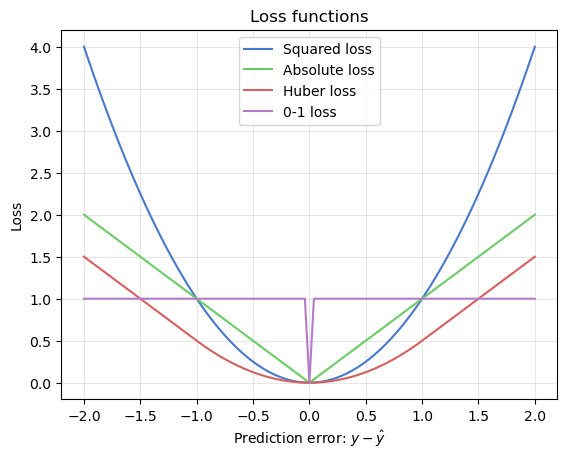

In [24]:
fig, ax = plt.subplots()

# Define our x-axis (linearly spaced values between -2 and 2)
xs = np.linspace(-2, 2, 101)
ys = np.zeros_like(xs)


# Plot our loss functions
ax.plot(xs, squared_loss(ys, xs), label='Squared loss')
ax.plot(xs, absolute_loss(ys, xs), label='Absolute loss')
ax.plot(xs, huber_loss(ys, xs), label='Huber loss')
ax.plot(xs, zero_one_loss(ys, xs), label='0-1 loss')

# Add some plot aesthetics
ax.set_xlabel(r"Prediction error: $y - \hat{y}$")
ax.set_ylabel("Loss")
ax.set_title("Loss functions")
ax.grid(alpha=0.3)

ax.legend()


#### ➡️ ✏️ Task 2
Looking at the above plot, discuss the following questions with your classmates:
1. If your predictor predicts perfectly, i.e., $\hat{y} = y$, does the loss function matter?
2. If your prediction error $y - \hat{y} = 0.5$, which loss is the more forgiving: the absolute loss or the squared loss?
3. What if instead the prediction error is $y - \hat{y} = 1.5$?
4. Why would one prefer the squared loss over the absolute loss or vice versa? (*Hint*: Read the description of the Huber loss again.)
5. Have you noticed that all of the above loss functions are symmetric around $y - \hat{y} = 0$? Why is that? What would happen if they were not symmetric? Can you imagine a case where we would prefer a non-symmetric loss?

#### ➡️ ✏️ Task 3
Repeat the above plot, but do the following:
1. Change the values for `xs` to be linearly spaced between `-5` and `5`.
2. Remove the 0-1 loss.
3. Add Huber loss with $\delta=\frac{1}{2}$, $\delta=2$, and $\delta=5$.

What do you notice? Discuss with your classmates.

In [25]:
# ➡️ Your code here...

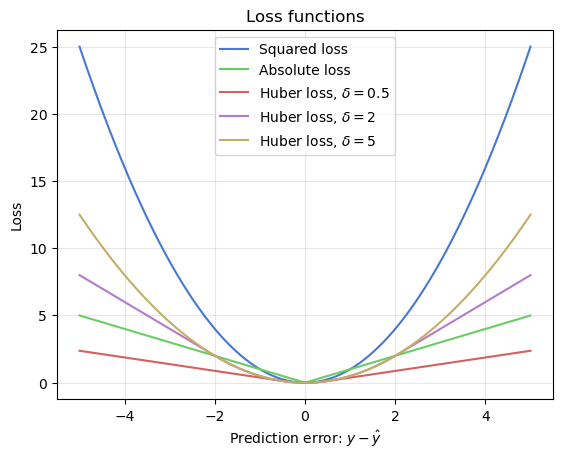

In [10]:
# SOLUTION
fig, ax = plt.subplots()

# Define our x-axis (now linearly spaced values between -5 and 5)
xs = np.linspace(-5, 5, 1001)
ys = np.zeros_like(xs)


# Plot our loss functions
ax.plot(xs, squared_loss(ys, xs), label='Squared loss')
ax.plot(xs, absolute_loss(ys, xs), label='Absolute loss')
ax.plot(xs, huber_loss(ys, xs, delta = 0.5), label=r'Huber loss, $\delta = 0.5$')
ax.plot(xs, huber_loss(ys, xs, delta = 2), label=r'Huber loss, $\delta = 2$')
ax.plot(xs, huber_loss(ys, xs, delta = 5), label=r'Huber loss, $\delta = 5$')


# Add some plot aesthetics
ax.set_xlabel(r"Prediction error: $y - \hat{y}$")
ax.set_ylabel("Loss")
ax.set_title("Loss functions")
ax.grid(alpha=0.3)

ax.legend()


___

## Empirical Risk Minimization

Now that we understand how different loss functions act as a measure of the quality of our predictions, we can focus on using them to find a good predictor $\hat{f}$.

Recall that we would like to pick a predictor $\hat{f}$ out of a larger set of possible predictors: our *hypothesis class* $\mathcal{H}$. We will discuss the concept of hypothesis classes in more detail later on. For now, let us assume that we receive a finite set of possible predictors $\mathcal{H} = \{f_1, f_2, \dots f_n\}$ and we would like to pick the best one.

### US Crop Yields
We begin by considering a scenario where we are interested in predicting the crop yield of a field. We have a dataset $\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^n$ consisting of $n=100$ observations of crops in the US, with average temperature $x^{(i)}$ and crop yield $y^{(i)}$. 

In [11]:
# Load data about US crop yields based on temperature
crops = pd.read_csv("data/us_crops.csv")
crops.head()

,temp,yield
0,16.64,462.771538
1,11.37,725.362676
2,12.52,776.967318
3,13.79,718.718013
4,11.97,533.642120


Suppose we given the following hypothesis class $\mathcal{H}$ of possible predictors:
$$\begin{align*}
\mathcal{H} &= \{f_1, f_2, \dots f_6\}, \text{ where} \\
f_1(x) &= 639 &&\text{(constant predictor)} \\
f_2(x) &= 1000 - 45x\\
f_3(x) &= 1010 - 30x\\
f_4(x) &= 1020 - 9.5x - 1.5x^2\\
f_5(x) &= 800 + 40x - 3.5x^2\\
f_6(x) &= 400 + 30x + 2.9x^2 - 0.25x^3,
\end{align*}$$

and we would like to pick the best predictor out of this set.

In [12]:
# Hypotheses are functions that take our input data and return a prediction
hypotheses = [
    lambda x: 639 * np.ones_like(x),
    lambda x: 1200 - 45 * x,
    lambda x: 1010 - 30 * x,
    lambda x: 1020 - 9.5 * x - 1.5 * x ** 2,
    lambda x: 800 + 40 * x - 3.5 * x ** 2,
    lambda x: 300 + 30 * x + 2.9 * x ** 2 - 0.25 * x ** 3,
]

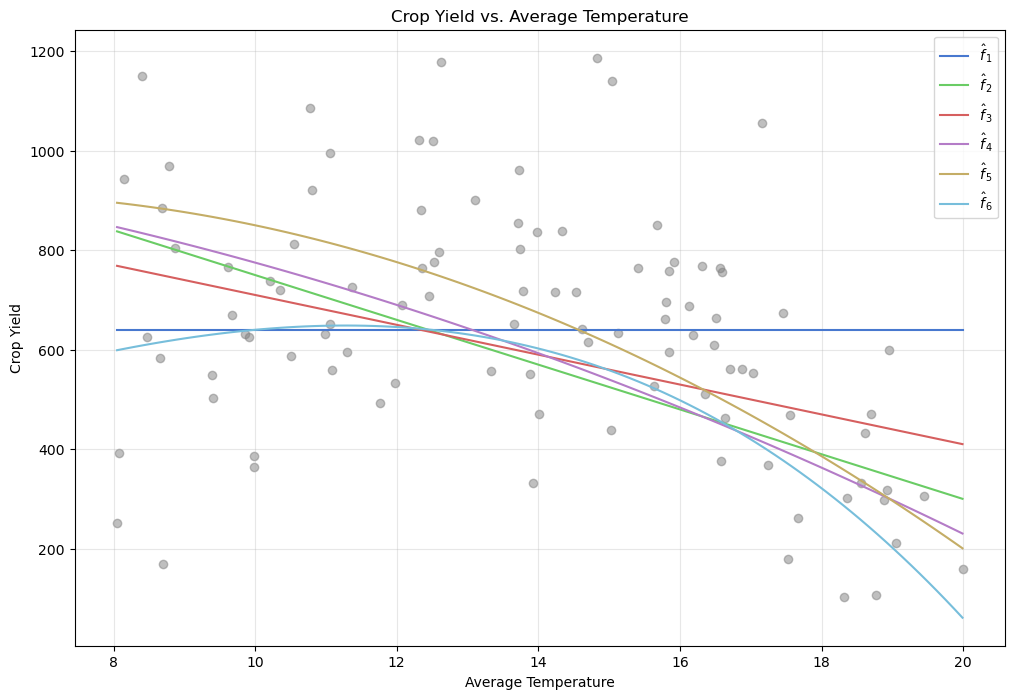

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the individual observations
ax.scatter(crops["temp"], crops["yield"], alpha=.5, color="gray")

# Create a grid of x values to make predictions for
xs = np.linspace(crops["temp"].min(), crops["temp"].max(), 100)

# Plot the hypotheses
for i, f in enumerate(hypotheses):
    ax.plot(xs, f(xs), label=fr"$\hat f_{i+1}$")

ax.set_title("Crop Yield vs. Average Temperature")
ax.set_xlabel("Average Temperature")
ax.set_ylabel("Crop Yield")
ax.legend()
ax.grid(alpha=0.3)

In [14]:
# Example for extracting information about a particular fhat

# Define the loss function we want to use
loss = squared_loss

# Choose a predictor to evaluate
predictor = hypotheses[0]

# Compute predictions for the chosen predictor
y_hat = predictor(crops["temp"])

# Compute the losses across the dataset
losses = loss(crops["yield"], y_hat)

print(f"The empirical risk of the constant predictor is: {losses.mean():.2f}")

The empirical risk of the constant predictor is: 59662.42


#### ➡️ ✏️ Task 4
First, make sure you thoroughly understand the code cell above. Once you do, implement the following:
1. Write a loop that iterates over the hypotheses and computes the squared loss for each hypothesis.
2. Find the hypothesis with the smallest squared loss and print it out.

In [15]:
# ➡️ Complete the code below

loss = squared_loss # Define the loss function we want to use

all_losses = [] # Use this list to store the losses for each predictor/hypothesis

# Extend the following code
for i, f in enumerate(hypotheses): # (i is the number of the hypothesis, and f is the function itself.)
    # Compute the predictions
    # ➡️ y_hat = [your code goes here...]

    # Compute the losses
    # ➡️ losses =  [your code goes here...]

    # Store the empirical risk
    all_losses.append(losses.mean())

# Print out the predictor with the lowest empirical risk
print(f"Predictor with lowest empirical risk: f{np.argmin(all_losses) + 1}",
      f"with empirical risk: {np.min(all_losses):.2f}")

Predictor with lowest empirical risk: f1 with empirical risk: 59662.42


In [16]:
# SOLUTION
loss = squared_loss # Define the loss function we want to use

all_losses = [] # Use this list to store the losses for each predictor

# Extend the following code
for i, f in enumerate(hypotheses): # (i is the number of the hypothesis, and f is the function itself.)
    # Compute the predictions
    y_hat = f(crops["temp"])

    # Compute the losses
    losses = loss(crops["yield"], y_hat)

    # Store the empirical risk
    all_losses.append(losses.mean())

display(np.round(all_losses, 3))

# Print out the predictor with the lowest empirical risk
print(f"Predictor with lowest empirical risk: f{np.argmin(all_losses) + 1}",
      f"with empirical risk: {np.min(all_losses):.2f}")

array([59662.421, 59266.003, 53964.192, 57791.77 , 54545.054, 54043.031])

Predictor with lowest empirical risk: f3 with empirical risk: 53964.19


#### ➡️ ✏️  Task 5

Repeat task 4, but this time compute the squared loss, the absolute loss and different Huber losses ($\delta = 0.5, 1, 2, 5$) for each hypothesis, do you notice anything different? Discuss with your classmates.

HINTS: 

Start with a list that collects the different loss functions:

```python
loss_functions = {
    "absolute loss": absolute_loss,
    "squared loss": squared_loss,
    "huber loss (delta=0.5)": lambda y, y_hat: huber_loss(y, y_hat, delta=0.5),
    # [Fill huber loss for delta = 1],
    # [Fill huber loss for delta = 2],
    # [Fill huber loss for delta = 5]
}
```

Then use a loop:

```python
for loss_name, loss in loss_functions.items():
    all_losses = [] # Use this list to store the losses for each predictor

    for i, f in enumerate(hypotheses):
        # Compute the predictions
        y_hat = ...

        # Compute the losses
        losses = ...
    
        # Store the empirical risk
        all_losses.append(losses.mean())


# Print out the predictor with the lowest empirical risk
    print(f"For {loss_name}, the predictor with lowest empirical risk: f{np.argmin(all_losses) + 1}",
          f"with empirical risk: {np.min(all_losses):.2f}")
```

Note that **there should be one output from print() for every loss function!**

In [17]:
# ➡️ Your code goes here ...



In [18]:
# SOLUTION

loss_functions = {
    "absolute loss": absolute_loss,
    "squared loss": squared_loss,
    "huber loss (delta=0.5)": lambda y, y_hat: huber_loss(y, y_hat, delta=0.5),
    "huber loss (delta=1)": lambda y, y_hat: huber_loss(y, y_hat, delta=1),
    "huber loss (delta=2)": lambda y, y_hat: huber_loss(y, y_hat, delta=2),
    "huber loss (delta=5)": lambda y, y_hat: huber_loss(y, y_hat, delta=5)
}

for loss_name, loss in loss_functions.items():
    all_losses = [] # Use this list to store the losses for each predictor
    
    # Extend the following code
    for i, f in enumerate(hypotheses):
        # Compute the predictions
        y_hat = f(crops["temp"])
    
        # Compute the losses
        losses = loss(crops["yield"], y_hat)
    
        # Store the empirical risk
        all_losses.append(losses.mean())
    
    # Print out the predictor with the lowest empirical risk
    print(f"For {loss_name}, the predictor with lowest empirical risk: f{np.argmin(all_losses) + 1}",
          f"with empirical risk: {np.min(all_losses):.2f}")

For absolute loss, the predictor with lowest empirical risk: f5 with empirical risk: 179.53
For squared loss, the predictor with lowest empirical risk: f3 with empirical risk: 53964.19
For huber loss (delta=0.5), the predictor with lowest empirical risk: f5 with empirical risk: 89.64
For huber loss (delta=1), the predictor with lowest empirical risk: f5 with empirical risk: 179.03
For huber loss (delta=2), the predictor with lowest empirical risk: f5 with empirical risk: 357.07
For huber loss (delta=5), the predictor with lowest empirical risk: f5 with empirical risk: 885.27


___
#### 🤔 Pause and ponder

In this example, we have received a finite set of possible predictors $\mathcal{H} = \{f_1, f_2, \dots f_6\}$ and we have identified the best one out of this set, given a specific loss function. However, this list of predictors was predefined and limited in scope. How can we find a good predictor in a more general setting, i.e., when we do not receive a finite set of possible predictors?

Can you think of a way to find a good predictor in a more general setting? Discuss with your classmates.

*Hint:* Consider the mathematical minimization problem: $$\min_{f \in \mathcal{H}} \frac{1}{n} \sum_{i=1}^n \ell(y^{(i)}, f(\mathbf{x}^{(i)})),$$

can you think of a way to solve this problem for a hypothesis class with infinitely many members? 

Or perhaps a way to make this problem easier to solve? Think about the concept of parameters... Can you connect the dots?

... In any case, this is the topic of the next lecture!